# In this model we want to do the following:
- Model the white light curve for both visits
- Use fit results to fix the ramp and breathing parameters

In [1]:
import warnings
warnings.filterwarnings("ignore", message="It appears that you're using a Mac with one of Apple's ARM-based processors")

# We need to import numpyro first (though we use it last)
import numpyro
from numpyro.infer import MCMC, NUTS
from numpyro import distributions as dist
N_cores = 18
numpyro.set_host_device_count(N_cores)

from preamble_jax import *

jax.devices()

2025-09-18 15:19:03,681 - WARNING - File .dacerc not found. You are requesting data in public mode. To change this behaviour, create a .dacerc file in your home directory and fill it with your API key. More infos on https://dace.unige.ch


[CpuDevice(id=0),
 CpuDevice(id=1),
 CpuDevice(id=2),
 CpuDevice(id=3),
 CpuDevice(id=4),
 CpuDevice(id=5),
 CpuDevice(id=6),
 CpuDevice(id=7),
 CpuDevice(id=8),
 CpuDevice(id=9),
 CpuDevice(id=10),
 CpuDevice(id=11),
 CpuDevice(id=12),
 CpuDevice(id=13),
 CpuDevice(id=14),
 CpuDevice(id=15),
 CpuDevice(id=16),
 CpuDevice(id=17)]

🌈🤖 It looks like you're trying to bin in wavelength for a
`Rainbow` object that might not be normalized. In the
current version of `chromatic`, binning before normalizing
might give inaccurate results if the typical uncertainty
varies strongly with wavelength.

Please consider normalizing first, for example with
`rainbow.normalize().bin(...)`
so that all uncertainties will effectively be relative,
and the inverse variance weighting used for binning
wavelengths together will give more reasonable answers.

If you really need to bin before normalizing, please submit
an Issue at github.com/zkbt/chromatic/, and we'll try to
prioritize implementing a statistically sound solution as
soon as possible!



  0%|          | 0/160 [00:00<?, ?it/s]

🌈🤖 The time scale for this rainbow is '?',
and there are 160 time centers and
160 time edges defined.

It's hard to imshow something with a time axis
that isn't linearly or logarithmically uniform, or doesn't
at least have its time edges defined. We're giving up
and just using the time index as the time axis.

If you want a real time axis, one solution would be
to use `rainbow.pcolormesh()` instead of `rainbow.imshow()`.
It takes basically the same inputs but can handle non-uniform
grids.

Or, you could bin your times to a more uniform grid with
`binned = rainbow.bin(dt=...)` (for linear times) and then
`binned.imshow()` will give more informative axes.



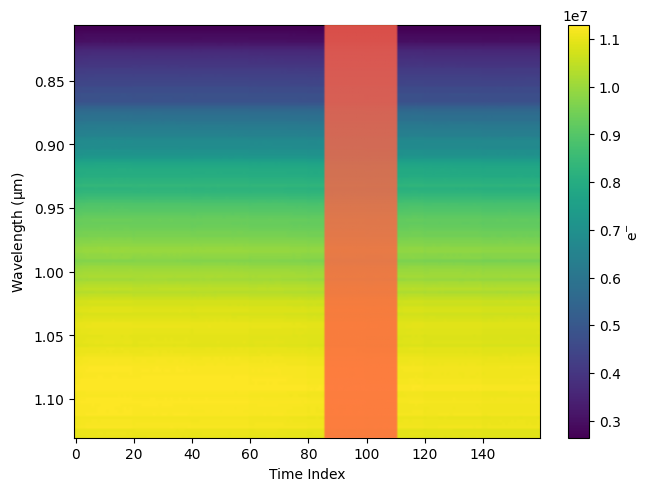

  0%|          | 0/160 [00:00<?, ?it/s]

<Figure size 640x480 with 0 Axes>

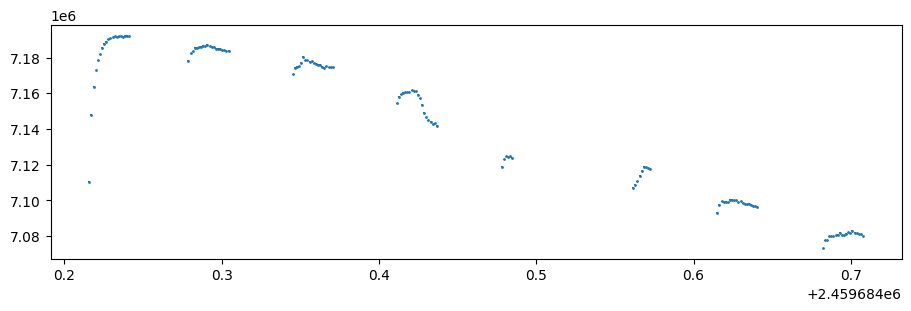

<Figure size 640x480 with 0 Axes>

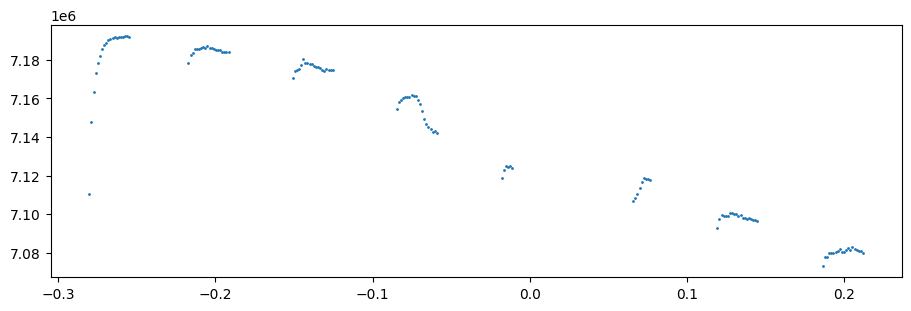

<Figure size 640x480 with 0 Axes>

In [2]:
visit = 'S22'

orbits_to_exclude = np.array([0]) if visit=='F21' else np.array([0,2,7])
err_factor = F21_SED_err_factor if visit=='F21' else S22_SED_err_factor
lc_index = 1 if visit=='F21' else 0
bin_edges = jnp.array([0.805,1.135,1.645]) * u.micron

predicted_T0 = visits[f'{visit}']['T0 (BJD_TDB)'].value
binwidth = visits[f'{visit}']['native resolution']
exptime = visits[f'{visit}']['exp (s)']
grism = visits[f'{visit}']['Grism']

rainbow = read_rainbow(f"../data/{visit}_scan-combined_trimmed_pacman_spec.rainbow.npy")
speclc_rainbow = rainbow
binned_for_model = rainbow.bin(wavelength_edges=bin_edges)
fleck_wavelengths = binned_for_model.wavelength.value

'Adjust uncertainties and bin the rainbow'
for i in range(len(rainbow.wavelength.value)):
    speclc_rainbow.uncertainty[i,:] = rainbow.uncertainty[i,:] * err_factor[i]

'remove the spots'
# speclc_rainbow.timelike["ok"] = np.random.uniform(0, 1, speclc_rainbow.ntime) < 1
# speclc_rainbow.timelike["ok"][:20] = False
# speclc_rainbow.timelike["ok"][-20:] = False

trim_spots = ( speclc_rainbow.trim().mask_transit(period=8.463*u.day, t0=(predicted_T0+0.027)*u.day, duration=0.075*u.day) )

trim_spots.imshow()
plt.show()
plt.clf()

trimmed_rainbow = trim_spots.trim().get_average_lightcurve_as_rainbow()
trimmed_rainbow.time = trimmed_rainbow.time + (predicted_T0+0.027)*u.day

plt.figure(figsize=(9,3))
plt.errorbar(trimmed_rainbow.time,trimmed_rainbow.flux.flatten(),trimmed_rainbow.uncertainty.flatten(),
            fmt='o',ms=1)
plt.show()
plt.clf()

data_wavelengths = speclc_rainbow.wavelength.value
img_date = trimmed_rainbow.time.value
data_flux = trimmed_rainbow.flux.flatten().value
relative_err = trimmed_rainbow.uncertainty.flatten().value/data_flux
time_from_T0 = img_date - predicted_T0

plt.figure(figsize=(9,3) )
plt.errorbar(time_from_T0,data_flux,yerr=relative_err,fmt='o',ms=1)
plt.show()
plt.clf()

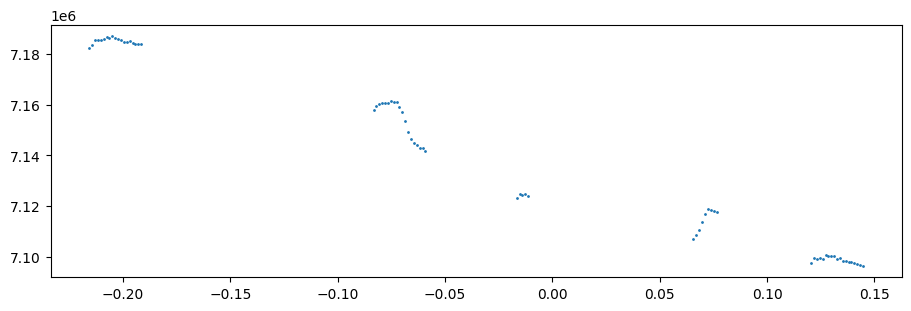

<Figure size 640x480 with 0 Axes>

In [3]:
# Label the orbits
orbit = np.zeros_like(img_date)
for j in range(len(img_date)):
    if j >= 1:
        if (img_date[j] - img_date[j - 1]) > 0.01:
            orbit[j] = (orbit[j - 1] + 1)
        else:
            orbit[j] = orbit[j - 1]

# Trim the first point from each orbit
ref_time = []
for o in np.unique(orbit):
    first_index = np.where(orbit == o)[0][0]
    ref_time.append(img_date[first_index])
    data_flux[first_index] = np.nan  # Set the first point of each subsequent orbit to np.nan
    relative_err[first_index] = np.nan
    img_date[first_index] = np.nan
    time_from_T0[first_index] = np.nan

# Set data to nan if it was in the pre-defined list of orbits to exclude
for orbit_to_exclude in orbits_to_exclude:
    data_flux[orbit == orbit_to_exclude] = np.nan
    relative_err[orbit == orbit_to_exclude] = np.nan
    img_date[orbit == orbit_to_exclude] = np.nan
    time_from_T0[orbit == orbit_to_exclude] = np.nan

plt.figure(figsize=(9,3) )
plt.errorbar(time_from_T0,data_flux,yerr=relative_err,fmt='o',ms=1)
plt.show()
plt.clf()

# Populate ramp_phase time arrays
phase_list=[]
for o in [0,1,2,3,4,5,6,7]:
    rphase = (img_date[orbit==o] - ref_time[o]) / default_params['HST_period']
    phase_list.append(rphase)
ramp_phase = np.concatenate(phase_list)
breathing_phase = ( (img_date-ref_time[0]+0.02) / default_params['HST_period'] ) % 1

# plt.figure(figsize=(9,3) )
# plt.errorbar(ramp_phase,data_flux,yerr=relative_err,fmt='o',ms=1)
# plt.show()
# plt.clf()

# plt.figure(figsize=(9,3) )
# plt.errorbar(breathing_phase,data_flux,yerr=relative_err,fmt='o',ms=1)
# plt.show()
# plt.clf()

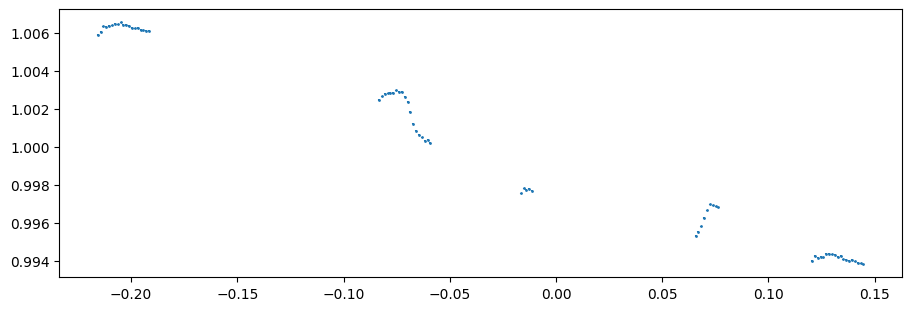

<Figure size 640x480 with 0 Axes>

In [4]:
# Convert all arrays to JAX arrays
_data_flux = jnp.array( data_flux[~np.isnan(time_from_T0)] )
data_flux = _data_flux[~jnp.isnan(_data_flux)]
_relative_err = jnp.array(relative_err[~np.isnan(time_from_T0)] )
relative_err = _relative_err[~jnp.isnan(_data_flux)]
_img_date = jnp.array(img_date[~np.isnan(time_from_T0)] )
img_date = _img_date[~jnp.isnan(_data_flux)]
_time_from_T0 = jnp.array(time_from_T0[~np.isnan(time_from_T0)] )
time_from_T0 = _time_from_T0[~jnp.isnan(_data_flux)]
_ramp_phase = jnp.array(ramp_phase[~np.isnan(ramp_phase)] )
ramp_phase = _ramp_phase[~jnp.isnan(_data_flux)]
_breathing_phase = jnp.array(breathing_phase[~np.isnan(breathing_phase)] )
breathing_phase = _breathing_phase[~jnp.isnan(_data_flux)]

normalized_data_flux = data_flux/jnp.mean(data_flux)
normalized_relative_err = relative_err*normalized_data_flux

plt.figure(figsize=(9,3) )
plt.errorbar(time_from_T0,normalized_data_flux,yerr=normalized_relative_err,fmt='o',ms=1)
plt.show()
plt.clf()

In [5]:
def numpyro_model():

    """
    Define the probabilistic model in NUMPYRO
    """
    params = {}

    # Instrument Parameters
    params['r_1'] = numpyro.sample('r_1', dist.Uniform(2.0, 20.0))
    params['r_2'] = numpyro.sample('r_2', dist.Uniform(-8, -4))
    params['r_3'] = numpyro.sample('r_3', dist.Uniform(-0.001,0.0002))  

    # Instrument Parameters
    params['b_1'] = numpyro.sample('b_1', dist.Uniform(0,0.12))
    params['b_2'] = numpyro.sample('b_2', dist.Uniform(-0.5,0))
    params['b_3'] = numpyro.sample('b_3', dist.Uniform(0,0.5)) 
    params['b_4'] = numpyro.sample('b_4', dist.Uniform(-0.3,0)) 

    # Baseline Parameters
    # params['linear_slope'] = numpyro.sample('linear_slope', dist.Uniform(-0.04, -0.02))
    params['spot_lat'] = numpyro.sample('spot_lat', dist.Uniform(0.6, 2.0))
    params['spot_lon'] = numpyro.sample('spot_lon', dist.Uniform(-1.4, -0.6))
    params['spot_rad'] = numpyro.sample('spot_rad', dist.Uniform(0.0, 0.5))

    # Planet Parameters
    params['rp_rs'] = numpyro.sample('rp_rs', dist.Uniform(0.04, 0.052))
    params['t_0'] = numpyro.sample('t_0', dist.Uniform(0, 0.0015)) 
    params['a'] = numpyro.sample('a', dist.Uniform(18.0, 20.0))
    
    params['u1'] = numpyro.sample('u1', dist.Uniform(0.1,0.45))
    params['u2'] = numpyro.sample('u2', dist.Uniform(0.1,0.7))
    
    # Stellar Parameters
    params['T_phot'] = 4200
    params['T_spot'] = numpyro.sample('T_spot', dist.Uniform(3000,3600))
    beta = numpyro.sample('beta', dist.Uniform(0, 0.6))

    @jit
    def broadband_transit(params,**kwargs):

         # Calculate systematics model
        ramp = ramp_model_jax(phase=ramp_phase,
                        r1=jnp.asarray(params['r_1'], dtype=jnp.float64),
                        r2=jnp.asarray(params['r_2'], dtype=jnp.float64),
                        r3=jnp.asarray(params['r_3'], dtype=jnp.float64) )
        breathing = breathing_model_jax(phase=breathing_phase,
                                  b1=jnp.asarray(params['b_1'], dtype=jnp.float64),
                                  b2=jnp.asarray(params['b_2'], dtype=jnp.float64),
                                  b3=jnp.asarray(params['b_3'], dtype=jnp.float64),
                                  b4=jnp.asarray(params['b_4'], dtype=jnp.float64))
        
        # linear_baseline = linear_model_jax(x=time_from_T0,
        #                                    m=jnp.asarray(params['linear_slope'], dtype=jnp.float64) )
        systematics = (breathing * ramp )#* linear_baseline)
        # systematics = _systematics/jnp.mean(_systematics)
        
        # Update Planet Parameters
        planet_parameters = dict(
            inclination = np.radians(default_params['planet_i']),
            a = jnp.asarray(params['a'], dtype=jnp.float64),
            rp = jnp.asarray(params['rp_rs'], dtype=jnp.float64),
            period = 8.46,
            t0 = jnp.asarray(params['t_0'], dtype=jnp.float64),
            ecc = 0.0,
            u1 = jnp.asarray(params['u1'], dtype=jnp.float64),
            u2 = jnp.asarray(params['u2'], dtype=jnp.float64))
        
        # Get spectra for the model temps
        Phot = get_binned_BTSettl_spectrum_jax(T=4200,data_wave = fleck_wavelengths)
        Cool = get_binned_BTSettl_spectrum_jax(T=params['T_spot'],data_wave = fleck_wavelengths)
        
        # Update stellar parameters
        active_star = ActiveStar(
        times = time_from_T0,
        inclination=jnp.radians(default_params['stellar_i']),
        T_eff=jnp.asarray(4200, dtype=jnp.float64),
        wavelength=Phot[0]*1e-6, # m
        phot=Phot[1],
        P_rot=default_params['P_rot'])
        
        active_star.spectrum = jnp.concatenate([
        jnp.vstack([Cool[1]]),
        ])
        active_star.temperature = jnp.concatenate([
            jnp.array([params['T_spot']]),
        ])
        active_star.rad = jnp.concatenate([
            jnp.array([params['spot_rad']]),
        ])
        active_star.lon = jnp.concatenate([
            jnp.array([params['spot_lon']]),
        ])
        active_star.lat = jnp.concatenate([
            jnp.array([params['spot_lat']]),
        ])
        
        lc, contam, X, Y, spectrum_at_transit = active_star.transit_model(**planet_parameters)        
        lc_model = lc.T[lc_index] * systematics
        mean_per_wavelength = jnp.mean(lc_model)
        normalized_model = lc_model / mean_per_wavelength
    
        return normalized_model

    numpyro.sample(
        "Obs", dist.Normal(
            loc=broadband_transit(params), 
            scale=(10**beta)*normalized_relative_err,
        ), obs=normalized_data_flux
    )

In [6]:
n_temps = 3
n_warmup = 2_00
n_samples = 2_000
n_chains = 14 # 14, 11, 9, 7, 6, 5, 4 (best options, could do a comparison to determine the best)

model_designation = f'{visit}_{n_temps}T_{n_samples}_{n_chains}chains_whitelight'

In [ ]:
rng_key = PRNGKey(10)

sampler = NUTS(
    numpyro_model,
    dense_mass=True)

mcmc = MCMCWithCheckpoints(
    sampler, 
    num_warmup=n_warmup, 
    num_samples=n_samples,
    num_chains=n_chains
)

mcmc.run_checkpoints(rng_key, n_checkpoints=4, on_checkpoint=post_batch_viz_save)

mcmc.print_summary()                                                                        

# arviz converts a numpyro MCMC object to an `InferenceData` object based on xarray:
result = arviz.from_numpyro(mcmc)

  0%|          | 0/5 [00:00<?, ?it/s]




Begin warmup





  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

...

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

Corner for checkpoint 0


In [ ]:
'Save the result'
result.to_netcdf(f'../data/samples/{model_designation}')

'Print the summary'
arviz.summary(result)

In [ ]:
'Examine the Leave-One-Out (LOO) summary'
loo = arviz.loo(result, pointwise=True)
loo